# Построение агентной системы на Python

Данная работа посвящена построению агентных систем на LangChain и LangGraph.

Данная работа выполнена студентом ИАД-4 Коноваловым Матвеем и опирается на семинарские ноутбуки.

## В чём разница между LangChain и LangGraph

| Характеристика | LangChain Agents | LangGraph Agents |
|----------------|-----------------|-----------------|
| Кто управляет логикой | Модель (LLM) | Разработчик |
| Гибкость | Ограничена | Абсолютная |
| Сложность | Простые / средние задачи | Сложные воркфлоу |
| Предсказуемость | Низкая | Высокая |
| Память | Минимальная | Любая, структурированная |
| Подходит для продакшена | Иногда | Да |

---

## Вывод

- **LangChain Agents** — быстрый способ собрать помощника: подключаем инструменты, выбираем тип агента, LLM сама решает, что делать.
- **LangGraph Agents** — контроль над каждым шагом: вы строите граф действий, LLM участвует только в отдельных узлах, что делает систему предсказуемой и надёжной.

**Итоговое правило:**
LangChain = “готовые блоки, которые магически вызывают инструменты”
LangGraph = “строим агента сами, LLM помогает на узлах, а логика полностью под нашим контролем”

## Инициализация LLM
LLM это неотъемлемая часть агентных систем, центральный мозг, вызывающий конкретные инструменты или выполняющий работу с текстом, так что без неё мы в этой работе не обойдемся.

Выбор модели проводился на основании [ранкинга LLM в категории Academia на OpenRouter](https://openrouter.ai/rankings?category=academia#categories) (поскольку обе агентных системы связаны с наукой)

In [ ]:
!pip install -qU langchain==0.3.25 langchain-openai==0.3.22 langchain-experimental==0.3.4 numexpr==2.11.0

In [5]:
from langchain_openai import ChatOpenAI
from constants import OPENROUTER_API_KEY

llm = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    temperature=0,
)

## ReAct-агент на LangChain

Было бы круто что-то придумать с md-подписями для клеток, и мб с написанием md-саммари (или хотя бы выводов).

И раз он многофункциональный, то можно ещё анализ кода на соответствие поставленной задаче закинуть.

## Агент на LangGraph
Агент должен обращаться по API, обрабатывать ответ LLM-кой и выдавать в ответе, причем должна решаться полезная для меня задача.

В ходе написания кода для исследований меня часто посещает вопрос "а точно ли то, чем я сейчас занимаюсь, не рассматривалось кем-то в статье?".

Поэтому мой агент будет читать мой код, искать релевантные статьи через API arXiv и саммаризировать для меня, какие вопросы полностью затрагивались, что упоминалось частично, а что представляет научную новизну.

In [2]:
!pip install -q langgraph==0.2.76 arxiv charset_normalizer

  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.83
    Uninstalling langchain-core-0.3.83:
      Successfully uninstalled langchain-core-0.3.83
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [langgraph]/6 [langchain-core]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.3.25 requires langchain-core<1.0.0,>=0.3.65, but you have langchain-core 1.2.20 which is incompatible.
langchain-experimental 0.3.4 requires langchain-core<0.4.0,>=0.3.28, but you have langchain-core 1.2.20 which is incompatible.
langchain 0.3.25 requires langchain-core<1.0.0,>=0.3.58, but you have langchain-core 1.2.20 which is incompatible.
langchain-openai 0.3.22 requires langchain-core<1.0.0,>=0.3.64, but you have langchain-core 1.2.20 which is incompatible.


In [102]:
from typing import TypedDict, List, Dict, Any, Optional, Tuple
import json
import textwrap
import arxiv
from langgraph.graph import START, END, StateGraph
import os
import re
import io
import tarfile
import posixpath
import sqlite3
import hashlib
import requests
import fitz  # PyMuPDF
from datetime import datetime

In [103]:
class AgentState(TypedDict, total=False):
    code: str
    code_summary: str
    extracted_signals: Dict[str, Any]
    algorithmic_structure: Dict[str, Any]
    queries: List[str]
    papers: List[Dict[str, str]]
    paper_algorithms: List[Dict[str, Any]]
    paper_matches: List[Dict[str, Any]]
    final_summary: str

In [104]:
VERBOSE = True
TOP_PAPERS_FOR_ALGO_EXTRACTION = 3
TOP_PAPERS_FOR_MATCHING = 12
TOP_PAPERS_FOR_DEEP_MATCHING = 6
ALGO_MATCH_SCORE_THRESHOLD = 0.45
ALGORITHM_DB_PATH = os.path.abspath("paper_algorithms_cache.sqlite3")

### Шаг 1. Извлечение сигналов из кода

Здесь LLM-ка, подобно backbone, извлекающему признаки с картинки, извлекает сигналы из кода, по которым дальше будет происходить поиск релевантных статей.

In [105]:
def clean_llm_json_text(text: str) -> str:
    cleaned = (text or "").strip()
    if cleaned.startswith("```json"):
        cleaned = cleaned[len("```json"):].strip()
    if cleaned.startswith("```"):
        cleaned = cleaned[len("```"):].strip()
    if cleaned.endswith("```"):
        cleaned = cleaned[:-3].strip()
    return cleaned


def parse_llm_json(text: str, fallback: Dict[str, Any]) -> Dict[str, Any]:
    cleaned = clean_llm_json_text(text)
    try:
        return json.loads(cleaned)
    except Exception:
        return fallback

In [106]:
def summarize_code(state: AgentState):
    prompt = f"""
Ты анализируешь код исследовательского проекта и готовишь его описание для поиска научных статей.

Нужно вернуть JSON-объект со следующими полями:
- task: краткое название задачи;
- method_kind: тип метода или эксперимента;
- keywords: список ключевых терминов из кода;
- concepts: список более общих исследовательских концептов;
- method_markers: список используемых технических методов и механизмов;
- search_hints: 3-6 коротких поисковых фраз для arXiv.

Вот несколько примеров method_markers (они не обязательно представлены и ты можешь использовать пример не из списка):
- важность через градиент выхода по промежуточному слою;
- feature-level objective;
- интегрирование по пути от baseline к входу;
- итеративная атака с проекцией в L_inf-шар;
- momentum update;
- hook на промежуточный слой;
- сравнение важных и атакованных фич;
- корреляционный или иной анализ связи важности и атаки.

Ответ верни строго в формате JSON без пояснений.

Код:
{state['code']}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("summarize_code raw result:\n", result)

    extracted_signals = parse_llm_json(
        result,
        {
            "task": "unknown",
            "method_kind": "unknown",
            "keywords": [],
            "concepts": [],
            "method_markers": [],
            "search_hints": []
        },
    )

    code_summary = textwrap.dedent(
        f"""
        Task: {extracted_signals.get('task', 'unknown')}
        Method kind: {extracted_signals.get('method_kind', 'unknown')}
        Keywords: {', '.join(extracted_signals.get('keywords', []))}
        Concepts: {', '.join(extracted_signals.get('concepts', []))}
        Method markers: {', '.join(extracted_signals.get('method_markers', []))}
        """
    ).strip()

    if VERBOSE:
        print("Parsed extracted_signals:", extracted_signals)

    return {
        "extracted_signals": extracted_signals,
        "code_summary": code_summary,
    }

### Шаг 2. Извлечение алгоритмической структуры и исследовательского вопроса

Одних общих сигналов недостаточно: для точного поиска статей нужно отдельно извлечь алгоритмический скелет кода. На этом шаге LLM формирует более строгую структуру: основной алгоритм, исследовательский вопрос, используемые методы, характерные шаги процедуры и ключевые фрагменты кода, которые потом пойдут в финальное сопоставление со статьями.

In [107]:
def extract_algorithmic_structure(state: AgentState):
    prompt = f"""
Ты анализируешь код исследовательского проекта. Тебе нужно извлечь не общую тему, а алгоритмическую структуру и исследовательский вопрос.

Верни строго JSON-объект со следующими полями:
- research_question: главный исследовательский вопрос или проверяемая гипотеза;
- algorithm_type: краткий тип алгоритма;
- algorithm_signature: список из 4-8 коротких шагов, описывающих основную процедуру;
- methods_used: список используемых методов и механизмов;
- implementation_markers: список важных технических деталей реализации;
- key_code_spans: список из 3-6 коротких фрагментов кода или псевдокода, которые лучше всего описывают основной алгоритм.

Важно:
- methods_used должен явно выделять используемые методы, например: gradient of class score w.r.t. intermediate features, path integration, feature attribution, feature-level attack objective, momentum iterative update, Linf projection, hook-based feature extraction, comparison of important vs attacked features, attribution/perturbation alignment analysis;
- algorithm_signature должен описывать именно ход алгоритма, а не просто перечислять ключевые слова;
- key_code_spans должны быть короткими, но содержательными и буквально опираться на код.

Ответ верни строго в формате JSON без пояснений.

Код:
{state['code']}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("extract_algorithmic_structure raw result:\n", result)

    algorithmic_structure = parse_llm_json(
        result,
        {
            "research_question": "unknown",
            "algorithm_type": "unknown",
            "algorithm_signature": [],
            "methods_used": [],
            "implementation_markers": [],
            "key_code_spans": []
        }
    )

    if VERBOSE:
        print("Parsed algorithmic_structure:", algorithmic_structure)

    return {"algorithmic_structure": algorithmic_structure}

### Шаг 3. Построение нескольких поисковых запросов

Чтобы повысить полноту поиска, агент строит не один запрос, а несколько: более буквальные и более концептуальные. Задача - накидать побольше статей и уже потом среди них выделить самые релевантные, ибо важно не пропустить ни одной статьи, которая повторяет подходы из кода

In [108]:
def build_queries(state: AgentState):
    signals = state["extracted_signals"]
    algorithmic_structure = state["algorithmic_structure"]

    prompt = f"""
На основе двух структур ниже составь от 8 до 12 поисковых запросов для arXiv.

Требования:
- запросы должны быть короткими;
- часть запросов должна быть буквальной (по терминам из кода), часть — по алгоритмической структуре, часть — по исследовательскому вопросу;
- если в структуре есть `search_hints`, обязательно используй их как основу хотя бы для части запросов;
- обязательно используй `methods_used`, `algorithm_signature` и `research_question`, а не только keywords;
- каждый запрос верни на новой строке;
- не нумеруй строки;
- не добавляй пояснения.

Общая структура:
{json.dumps(signals, ensure_ascii=False, indent=2)}

Алгоритмическая структура:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("build_queries raw result:\n", result)

    queries = [line.strip("-• \t") for line in result.splitlines() if line.strip()]
    queries = list(dict.fromkeys(queries))

    search_hints = signals.get("search_hints", [])
    queries.extend([hint for hint in search_hints if hint not in queries])
    queries = list(dict.fromkeys(queries))

    if VERBOSE:
        print("Queries:", queries)

    return {"queries": queries}

### Шаг 4. Поиск статей через arXiv API

Наконец этап без LLM, но с обращением по API. Для каждого запроса берём несколько результатов, после чего объединяем их и убираем дубликаты по названию статьи.

In [109]:
def get_papers(state: AgentState):
    queries = state["queries"]
    papers: List[Dict[str, str]] = []
    seen_titles = set()

    client = arxiv.Client(page_size=5, delay_seconds=0.5, num_retries=3)

    for query in queries:
        if VERBOSE:
            print(f"Searching arXiv for query: {query}")

        search = arxiv.Search(
            query=query,
            max_results=5,
            sort_by=arxiv.SortCriterion.Relevance,
        )

        try:
            for result in client.results(search):
                title_key = result.title.strip().lower()
                if title_key in seen_titles:
                    continue

                seen_titles.add(title_key)
                papers.append(
                    {
                        "query": query,
                        "title": result.title,
                        "summary": result.summary,
                        "published": str(result.published.date()),
                        "url": result.entry_id,
                    }
                )
        except Exception as e:
            if VERBOSE:
                print(f"arXiv request failed for query '{query}': {e}")

    if VERBOSE:
        print(f"Total unique papers found: {len(papers)}")

    return {"papers": papers}

### Шаг 5. Извлечение алгоритмов из найденных статей

Теперь агент сначала пытается извлечь алгоритм детерминированно — из TeX или PDF. Если это удаётся, результат сразу сохраняется в БД и потом переиспользуется. Если явного алгоритма нет, агент берёт релевантный кусок статьи или весь её текст и просит LLM восстановить алгоритм в виде описания или псевдокода. За один прогон в LLM для этого этапа отправляется не более трёх статей.

#### Большая клетка с логикой извлечения алгоритмов

In [110]:
ALGORITHM_ENV_PATTERNS = [
    r"\\begin\{algorithm\*?\}.*?\\end\{algorithm\*?\}",
    r"\\begin\{algorithmic\}.*?\\end\{algorithmic\}",
    r"\\begin\{algorithms\}.*?\\end\{algorithms\}",
    r"\\begin\{procedure\*?\}.*?\\end\{procedure\*?\}",
    r"\\begin\{lstlisting\}.*?\\end\{lstlisting\}",
]

STRONG_METHOD_SECTION_TITLE_PATTERNS = [
    r"^approach$",
    r"^approaches$",
    r"^method$",
    r"^methods$",
    r"^methodology$",
    r"^proposed method$",
    r"^proposed methods$",
    r"^proposed approach$",
    r"^proposed approaches$",
    r"^our method$",
    r"^our methods$",
    r"^our approach$",
    r"^our approaches$",
    r"^framework$",
    r"^proposed framework$",
    r"^our framework$",
    r"^algorithm$",
    r"^algorithms$",
    r"^attack$",
    r"^attack method$",
    r"^attack methods$",
    r"^attack formulation$",
    r"^threat model$",
    r"^problem formulation$",
    r"^formulation$",
    r"^model architecture$",
    r"^architecture$",
    r"^feature disruptive attack$",
]

WEAK_METHOD_SENTENCE_PATTERNS = [
    r"we propose",
    r"our method",
    r"our approach",
    r"the proposed method",
    r"the proposed approach",
    r"algorithm 1",
    r"procedure",
    r"optimization step",
    r"attack objective",
    r"iteratively update",
]

def init_algorithm_db(db_path: str = ALGORITHM_DB_PATH):
    conn = sqlite3.connect(db_path)
    conn.execute(
        """
        CREATE TABLE IF NOT EXISTS paper_algorithms_cache
        (
            cache_key
            TEXT
            PRIMARY
            KEY,
            paper_url
            TEXT,
            paper_title
            TEXT,
            published
            TEXT,
            query_text
            TEXT,
            source_type
            TEXT,
            algorithm_found
            INTEGER
            NOT
            NULL
            DEFAULT
            0,
            extraction_mode
            TEXT,
            algorithm_text
            TEXT,
            article_chunk
            TEXT,
            raw_payload_json
            TEXT
            NOT
            NULL,
            content_hash
            TEXT,
            created_at
            TEXT
            NOT
            NULL,
            updated_at
            TEXT
            NOT
            NULL
        )
        """
    )
    conn.commit()
    return conn


def make_paper_cache_key(paper: Dict[str, Any]) -> str:
    base = f"{paper.get('url', '').strip()}||{paper.get('title', '').strip().lower()}||{paper.get('published', '').strip()}"
    return hashlib.sha256(base.encode("utf-8")).hexdigest()


def load_cached_paper_algorithm(paper: Dict[str, Any], db_path: str = ALGORITHM_DB_PATH) -> Optional[Dict[str, Any]]:
    cache_key = make_paper_cache_key(paper)
    conn = init_algorithm_db(db_path)
    row = conn.execute(
        """
        SELECT raw_payload_json
        FROM paper_algorithms_cache
        WHERE cache_key = ?
        """,
        (cache_key,),
    ).fetchone()
    conn.close()
    if not row:
        return None
    try:
        return json.loads(row[0])
    except Exception:
        return None


def save_cached_paper_algorithm(
        paper: Dict[str, Any],
        payload: Dict[str, Any],
        source_type: str,
        algorithm_found: bool,
        extraction_mode: str,
        algorithm_text: str = "",
        article_chunk: str = "",
        db_path: str = ALGORITHM_DB_PATH,
):
    cache_key = make_paper_cache_key(paper)
    now = datetime.utcnow().isoformat(timespec="seconds") + "Z"
    raw_payload_json = json.dumps(payload, ensure_ascii=False)
    content_hash = hashlib.sha256(raw_payload_json.encode("utf-8")).hexdigest()

    conn = init_algorithm_db(db_path)
    conn.execute(
        """
        INSERT INTO paper_algorithms_cache (cache_key,
                                            paper_url,
                                            paper_title,
                                            published,
                                            query_text,
                                            source_type,
                                            algorithm_found,
                                            extraction_mode,
                                            algorithm_text,
                                            article_chunk,
                                            raw_payload_json,
                                            content_hash,
                                            created_at,
                                            updated_at)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?) ON CONFLICT(cache_key) DO
        UPDATE SET
            paper_url = excluded.paper_url,
            paper_title = excluded.paper_title,
            published = excluded.published,
            query_text = excluded.query_text,
            source_type = excluded.source_type,
            algorithm_found = excluded.algorithm_found,
            extraction_mode = excluded.extraction_mode,
            algorithm_text = excluded.algorithm_text,
            article_chunk = excluded.article_chunk,
            raw_payload_json = excluded.raw_payload_json,
            content_hash = excluded.content_hash,
            updated_at = excluded.updated_at
        """,
        (
            cache_key,
            paper.get("url", ""),
            paper.get("title", ""),
            paper.get("published", ""),
            paper.get("query", ""),
            source_type,
            int(bool(algorithm_found)),
            extraction_mode,
            algorithm_text,
            article_chunk,
            raw_payload_json,
            content_hash,
            now,
            now,
        ),
    )
    conn.commit()
    conn.close()


init_algorithm_db()


def _extract_arxiv_id_from_url(url: str) -> Optional[str]:
    if not url:
        return None
    m = re.search(r"arxiv\.org/(?:abs|pdf)/([^/?#]+)", url)
    if not m:
        return None
    return m.group(1).replace(".pdf", "")


def _download_url(url: str, timeout: int = 60) -> bytes:
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    return response.content


def _download_arxiv_source(arxiv_id: str) -> bytes:
    return _download_url(f"https://arxiv.org/e-print/{arxiv_id}")


def _download_arxiv_pdf(arxiv_id: str) -> bytes:
    return _download_url(f"https://arxiv.org/pdf/{arxiv_id}.pdf")


def _safe_decode_tex(raw: bytes) -> str:
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            return raw.decode(enc)
        except Exception:
            pass
    return raw.decode("utf-8", errors="ignore")


def _untar_source_files(archive_bytes: bytes) -> Dict[str, bytes]:
    files: Dict[str, bytes] = {}
    with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:*") as tar:
        for member in tar.getmembers():
            if not member.isfile():
                continue
            f = tar.extractfile(member)
            if f is None:
                continue
            files[member.name] = f.read()
    return files


def _strip_tex_comments(text: str) -> str:
    lines = []
    for line in text.splitlines():
        line = re.sub(r"(?<!\\)%.*$", "", line)
        lines.append(line)
    return "\n".join(lines)


def _guess_main_tex_file(tex_files: Dict[str, str]) -> Optional[str]:
    candidates = []
    for path, text in tex_files.items():
        score = 0
        lower_name = posixpath.basename(path).lower()
        if lower_name in {"main.tex", "paper.tex", "ms.tex", "arxiv.tex"}:
            score += 5
        if "\\documentclass" in text:
            score += 5
        if "\\begin{document}" in text:
            score += 3
        if "\\title" in text:
            score += 1
        candidates.append((score, len(text), path))
    if not candidates:
        return None
    candidates.sort(reverse=True)
    return candidates[0][2]


def _resolve_tex_inputs(text: str, tex_files: Dict[str, str], base_dir: str, depth: int = 0, max_depth: int = 8) -> str:
    if depth >= max_depth:
        return text

    pattern = re.compile(r"\\(?:input|include)\{([^}]+)\}")

    def repl(match):
        name = match.group(1).strip()
        candidates = [name, f"{name}.tex"]
        for candidate in candidates:
            joined = posixpath.normpath(posixpath.join(base_dir, candidate))
            if joined in tex_files:
                return _resolve_tex_inputs(tex_files[joined], tex_files, posixpath.dirname(joined), depth + 1,
                                           max_depth)
        return ""

    return pattern.sub(repl, text)


def _extract_tex_algorithm_blocks(text: str) -> List[str]:
    blocks: List[str] = []
    for pattern in ALGORITHM_ENV_PATTERNS:
        for match in re.finditer(pattern, text, flags=re.DOTALL | re.IGNORECASE):
            block = match.group(0).strip()
            if block:
                blocks.append(block)
    return list(dict.fromkeys(blocks))


def _normalize_title(title: str) -> str:
    title = re.sub(r"\\[a-zA-Z]+", " ", title)
    title = re.sub(r"[^a-zA-Z0-9 ]+", " ", title.lower())
    title = re.sub(r"\s+", " ", title).strip()
    return title


def _split_tex_sections(text: str) -> List[Dict[str, Any]]:
    pattern = re.compile(r"\\(section|subsection|subsubsection)\*?\{([^}]+)\}")
    matches = list(pattern.finditer(text))
    if not matches:
        return [{"title": "full_text", "level": 1, "content": text}]

    sections: List[Dict[str, Any]] = []
    for i, match in enumerate(matches):
        start = match.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        level_name = match.group(1)
        title = match.group(2).strip()
        level = {"section": 1, "subsection": 2, "subsubsection": 3}.get(level_name, 1)
        content = text[start:end].strip()
        sections.append({"title": title, "level": level, "content": content})
    return sections


def _is_strong_method_section(title: str) -> bool:
    normalized = _normalize_title(title)
    return any(re.search(p, normalized) for p in STRONG_METHOD_SECTION_TITLE_PATTERNS)


def _section_strength_score(section: Dict[str, Any]) -> float:
    title = section.get("title", "")
    content = section.get("content", "")
    score = 0.0
    if _is_strong_method_section(title):
        score += 10.0
    lowered = content.lower()
    for pattern in WEAK_METHOD_SENTENCE_PATTERNS:
        if re.search(pattern, lowered):
            score += 1.0
    score += min(len(content) / 4000.0, 3.0)
    if "experiment" in title.lower() or "results" in title.lower():
        score -= 3.0
    return score


def _choose_method_section(sections: List[Dict[str, Any]]) -> Optional[Dict[str, Any]]:
    if not sections:
        return None
    scored = sorted(sections, key=_section_strength_score, reverse=True)
    best = scored[0]
    if _section_strength_score(best) <= 0:
        return None
    return best


def _extract_text_from_pdf_bytes(pdf_bytes: bytes) -> str:
    doc = fitz.open(stream=pdf_bytes, filetype="pdf")
    parts = []
    for page in doc:
        txt = page.get_text("text")
        if txt and txt.strip():
            parts.append(txt.strip())
    doc.close()
    return "\n\n".join(parts)


def _extract_pdf_algorithm_block(pdf_text: str) -> str:
    match = re.search(
        r"(Algorithm\s*1[\s\S]{0,12000}?)(?:\n\s*(?:\d+\s+[A-Z][A-Za-z\- ]+|References)\b)",
        pdf_text,
        flags=re.IGNORECASE,
    )
    if match:
        return match.group(1).strip()
    match = re.search(r"Algorithm\s*1[\s\S]{0,8000}", pdf_text, flags=re.IGNORECASE)
    return match.group(0).strip() if match else ""


def extract_algorithm_from_arxiv_id(arxiv_id: str) -> Dict[str, Any]:
    result: Dict[str, Any] = {
        "algorithm_found": False,
        "source_type": "article_source",
        "extraction_mode": "unknown",
        "algorithm_text": "",
        "article_chunk": "",
        "whole_article_text": "",
        "decision_reason": "",
        "raw": {},
    }

    if not arxiv_id:
        result["extraction_mode"] = "no_arxiv_id"
        result["decision_reason"] = "No arXiv id was provided."
        return result

    try:
        source_bytes = _download_arxiv_source(arxiv_id)
        source_files = _untar_source_files(source_bytes)
    except Exception as e:
        source_files = {}
        result["raw"]["source_error"] = str(e)

    tex_files: Dict[str, str] = {}
    embedded_pdf_name = None
    for path, raw in source_files.items():
        low = path.lower()
        if low.endswith(".tex"):
            tex_files[path] = _strip_tex_comments(_safe_decode_tex(raw))
        elif low.endswith(".pdf") and embedded_pdf_name is None:
            embedded_pdf_name = path

    if tex_files:
        main_tex = _guess_main_tex_file(tex_files)
        if main_tex:
            expanded = _resolve_tex_inputs(tex_files[main_tex], tex_files, posixpath.dirname(main_tex))
            algo_blocks = _extract_tex_algorithm_blocks(expanded)
            if algo_blocks:
                result["algorithm_found"] = True
                result["extraction_mode"] = "tex_algorithm_block"
                result["algorithm_text"] = "\n\n".join(algo_blocks[:3])
                result["article_chunk"] = result["algorithm_text"]
                result["decision_reason"] = "Algorithm environment found in TeX source."
                result["raw"] = {"main_tex": main_tex, "algorithm_blocks_found": len(algo_blocks)}
                return result

            sections = _split_tex_sections(expanded)
            method_section = _choose_method_section(sections)
            if method_section is not None:
                result["algorithm_found"] = False
                result["extraction_mode"] = "tex_method_section"
                result["article_chunk"] = method_section.get("content", "")[:30000]
                result[
                    "decision_reason"] = f"No explicit algorithm block found; using method section '{method_section.get('title', '')}'."
                result["raw"] = {"main_tex": main_tex, "chosen_section": method_section.get("title", "")}
                return result

            result["extraction_mode"] = "whole_tex_fallback"
            result["article_chunk"] = expanded[:30000]
            result["whole_article_text"] = expanded[:30000]
            result["decision_reason"] = "No explicit method section found; using expanded TeX article text."
            result["raw"] = {"main_tex": main_tex}
            return result

    pdf_bytes = None
    try:
        if embedded_pdf_name and embedded_pdf_name in source_files:
            pdf_bytes = source_files[embedded_pdf_name]
            result["raw"]["embedded_pdf"] = embedded_pdf_name
        else:
            pdf_bytes = _download_arxiv_pdf(arxiv_id)
            result["raw"]["embedded_pdf"] = None
    except Exception as e:
        result["extraction_mode"] = "pdf_download_error"
        result["decision_reason"] = f"Failed to download PDF: {e}"
        return result

    try:
        pdf_text = _extract_text_from_pdf_bytes(pdf_bytes)
    except Exception as e:
        result["extraction_mode"] = "pdf_parse_error"
        result["decision_reason"] = f"Failed to parse PDF text: {e}"
        return result

    algo_block = _extract_pdf_algorithm_block(pdf_text)
    if algo_block:
        result["algorithm_found"] = True
        result["extraction_mode"] = "pdf_algorithm_block"
        result["algorithm_text"] = algo_block[:20000]
        result["article_chunk"] = result["algorithm_text"]
        result["decision_reason"] = "Algorithm block found in PDF text."
        return result

    result["extraction_mode"] = "whole_article_fallback"
    result["article_chunk"] = pdf_text[:30000]
    result["whole_article_text"] = pdf_text[:30000]
    result["decision_reason"] = "No explicit algorithm block found; using whole article PDF text."
    return result

#### Основная node для графа

In [111]:
def extract_paper_algorithms(state: AgentState):
    papers = state.get("papers", [])[:TOP_PAPERS_FOR_ALGO_EXTRACTION]
    paper_algorithms: List[Dict[str, Any]] = []

    for paper in papers:
        cached = load_cached_paper_algorithm(paper)
        if cached is not None:
            if VERBOSE:
                print(f"Loaded paper algorithm from cache for '{paper['title']}'")
            paper_algorithms.append(cached)
            continue

        arxiv_id = _extract_arxiv_id_from_url(paper.get("url", ""))
        if arxiv_id:
            source_extraction = extract_algorithm_from_arxiv_id(arxiv_id)
        else:
            source_extraction = {
                "algorithm_found": False,
                "source_type": "article_source",
                "extraction_mode": "no_arxiv_id",
                "algorithm_text": "",
                "article_chunk": "",
                "whole_article_text": "",
                "decision_reason": "No arXiv id in paper URL.",
                "raw": {},
            }

        if source_extraction["algorithm_found"]:
            prompt_source = source_extraction["algorithm_text"]
            source_type = "tex_or_pdf_algorithm"
        else:
            prompt_source = source_extraction["article_chunk"] or paper["summary"]
            source_type = "llm_fallback_from_article_text"

        if VERBOSE:
            print(f"Extracted source for '{paper['title']}'")
            print(f"Source type: {source_type}")
            print(f"Prompt source: {prompt_source}")

        prompt = f"""
У тебя есть краткая информация о научной статье. Извлеки из неё алгоритмическое описание.

Верни строго JSON-объект со следующими полями:
- title: название статьи;
- paper_task: основная задача статьи;
- paper_research_question: исследовательский вопрос статьи;
- paper_method_kind: тип метода;
- paper_algorithm_signature: список из 3-7 коротких шагов алгоритма или процедуры;
- paper_methods_used: список используемых методов и механизмов;
- paper_key_mechanisms: список ключевых технических идей статьи.

Статья:
Title: {paper['title']}
Published: {paper['published']}
Source query: {paper['query']}
URL: {paper['url']}

Текст для извлечения алгоритма:
{prompt_source[:30000]}
"""

        result = llm.invoke(prompt).content
        if VERBOSE:
            print(f"extract_paper_algorithms raw result for '{paper['title']}':\n", result)

        parsed = parse_llm_json(
            result,
            {
                "title": paper["title"],
                "paper_task": "unknown",
                "paper_research_question": "unknown",
                "paper_method_kind": "unknown",
                "paper_algorithm_signature": [],
                "paper_methods_used": [],
                "paper_key_mechanisms": []
            }
        )

        parsed["summary"] = paper["summary"]
        parsed["published"] = paper["published"]
        parsed["query"] = paper["query"]
        parsed["url"] = paper["url"]
        parsed["algorithm_found_directly"] = bool(source_extraction["algorithm_found"])
        parsed["extraction_mode"] = source_extraction.get("extraction_mode", "unknown")
        parsed["source_type"] = source_type
        parsed["algorithm_text"] = source_extraction.get("algorithm_text", "")
        parsed["article_chunk"] = source_extraction.get("article_chunk", "")
        parsed["decision_reason"] = source_extraction.get("decision_reason", "")

        save_cached_paper_algorithm(
            paper=paper,
            payload=parsed,
            source_type=source_type,
            algorithm_found=bool(source_extraction["algorithm_found"]),
            extraction_mode=source_extraction.get("extraction_mode", "unknown"),
            algorithm_text=source_extraction.get("algorithm_text", ""),
            article_chunk=source_extraction.get("article_chunk", ""),
        )
        paper_algorithms.append(parsed)

    if VERBOSE:
        print("Structured paper algorithms count:", len(paper_algorithms))

    return {"paper_algorithms": paper_algorithms}

### Шаг 6. Сопоставление кода и статей по алгоритмической структуре

Здесь сопоставление делается в два этапа. Сначала LLM получает несколько статей разом и выставляет каждой краткий рейтинг релевантности. Затем только статьи выше порога или top-n проходят в глубокое сопоставление. Это уменьшает число тяжёлых запросов и делает шаг 6 управляемым даже при 10-15 входных статьях.

In [112]:
def rank_papers_for_matching(state: AgentState) -> List[Dict[str, Any]]:
    algorithmic_structure = state["algorithmic_structure"]
    paper_algorithms = state.get("paper_algorithms", [])[:TOP_PAPERS_FOR_MATCHING]

    if not paper_algorithms:
        return []

    compact_papers = []
    for idx, paper in enumerate(paper_algorithms, start=1):
        compact_papers.append(
            {
                "index": idx,
                "title": paper.get("title", ""),
                "paper_task": paper.get("paper_task", ""),
                "paper_method_kind": paper.get("paper_method_kind", ""),
                "paper_algorithm_signature": paper.get("paper_algorithm_signature", []),
                "paper_methods_used": paper.get("paper_methods_used", []),
                "paper_key_mechanisms": paper.get("paper_key_mechanisms", []),
            }
        )

    prompt = f"""
У тебя есть структура алгоритма из кода и набор статей. Для каждой статьи выставь краткий рейтинг релевантности: насколько алгоритм в коде соотносится с алгоритмом из статьи.

Верни строго JSON-массив объектов со следующими полями:
- index: номер статьи из входного списка;
- title: название статьи;
- relevance_score: число от 0 до 1;
- keep_for_deep_match: true или false;
- short_reason: очень короткая причина на русском.

Структура алгоритма из кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Статьи:
{json.dumps(compact_papers, ensure_ascii=False, indent=2)}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("rank_papers_for_matching raw result:\n", result)

    cleaned = clean_llm_json_text(result)
    try:
        ranked = json.loads(cleaned)
    except Exception:
        ranked = []

    ranked_by_index = {item.get("index"): item for item in ranked if isinstance(item, dict)}
    enriched = []
    for idx, paper in enumerate(paper_algorithms, start=1):
        score_info = ranked_by_index.get(idx, {})
        enriched_paper = dict(paper)
        enriched_paper["relevance_score"] = float(score_info.get("relevance_score", 0.0) or 0.0)
        enriched_paper["keep_for_deep_match"] = bool(score_info.get("keep_for_deep_match", False))
        enriched_paper["short_reason"] = score_info.get("short_reason", "")
        enriched.append(enriched_paper)

    enriched.sort(key=lambda x: x.get("relevance_score", 0.0), reverse=True)
    filtered = [p for p in enriched if p.get("keep_for_deep_match") or p.get("relevance_score", 0.0) >= ALGO_MATCH_SCORE_THRESHOLD]
    if not filtered:
        filtered = enriched[:TOP_PAPERS_FOR_DEEP_MATCHING]
    return filtered[:TOP_PAPERS_FOR_DEEP_MATCHING]



def match_code_to_papers(state: AgentState):
    algorithmic_structure = state["algorithmic_structure"]
    candidate_papers = rank_papers_for_matching(state)
    paper_matches: List[Dict[str, Any]] = []

    for paper in candidate_papers:
        prompt = f"""
У тебя есть структура алгоритма из кода и структура алгоритма из статьи. Сопоставь их.

Верни строго JSON-объект со следующими полями:
- title: название статьи;
- match_level: one_to_one | partial | background;
- matched_steps: список шагов или идей, которые совпадают;
- missing_steps: список шагов или идей из кода, которых не видно в статье;
- method_overlap: список совпадающих методов и механизмов;
- verdict: короткий вывод на русском языке, насколько статья реально покрывает происходящее в коде.

Структура алгоритма из кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Структура статьи:
{json.dumps(paper, ensure_ascii=False, indent=2)}
"""

        result = llm.invoke(prompt).content
        if VERBOSE:
            print(f"match_code_to_papers raw result for '{paper['title']}':\n", result)

        parsed = parse_llm_json(
            result,
            {
                "title": paper["title"],
                "match_level": "background",
                "matched_steps": [],
                "missing_steps": [],
                "method_overlap": [],
                "verdict": "Не удалось надёжно сопоставить статью с кодом по алгоритмической структуре."
            }
        )

        parsed["published"] = paper.get("published", "")
        parsed["url"] = paper.get("url", "")
        parsed["paper_task"] = paper.get("paper_task", "")
        parsed["paper_method_kind"] = paper.get("paper_method_kind", "")
        parsed["relevance_score"] = paper.get("relevance_score", 0.0)
        parsed["short_reason"] = paper.get("short_reason", "")
        paper_matches.append(parsed)

    if VERBOSE:
        print("Structured paper matches count:", len(paper_matches))

    return {"paper_matches": paper_matches}

### Шаг 7. Финальное саммари найденных статей

Теперь LLM компактное описание кода плюс найденные статьи, а так же основные алгоритмы. По ним агент должен сделать итоговое саммари и разделить результаты на три уровня релевантности.

In [113]:
def summarize_papers(state: AgentState):
    papers = state.get("papers", [])
    algorithmic_structure = state.get("algorithmic_structure", {})
    paper_algorithms = state.get("paper_algorithms", [])
    paper_matches = state.get("paper_matches", [])

    if not papers:
        return {
            "final_summary": "По сформированным запросам статьи в arXiv найти не удалось. Возможно, запросы стоит расширить или сделать более общими."
        }

    papers_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {paper['title']}
                Published: {paper['published']}
                Source query: {paper['query']}
                Summary: {paper['summary']}
                URL: {paper['url']}
                """
            ).strip()
            for paper in papers[:15]
        ]
    )

    paper_algorithms_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {paper.get('title', '')}
                Paper task: {paper.get('paper_task', '')}
                Paper research question: {paper.get('paper_research_question', '')}
                Paper method kind: {paper.get('paper_method_kind', '')}
                Paper algorithm signature: {', '.join(paper.get('paper_algorithm_signature', []))}
                Paper methods used: {', '.join(paper.get('paper_methods_used', []))}
                Paper key mechanisms: {', '.join(paper.get('paper_key_mechanisms', []))}
                Direct algorithm found: {paper.get('algorithm_found_directly', False)}
                Extraction mode: {paper.get('extraction_mode', '')}
                Source type: {paper.get('source_type', '')}
                Decision reason: {paper.get('decision_reason', '')}
                URL: {paper.get('url', '')}
                """
            ).strip()
            for paper in paper_algorithms
        ]
    )

    paper_matches_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {match.get('title', '')}
                Match level: {match.get('match_level', '')}
                Matched steps: {', '.join(match.get('matched_steps', []))}
                Missing steps: {', '.join(match.get('missing_steps', []))}
                Method overlap: {', '.join(match.get('method_overlap', []))}
                Verdict: {match.get('verdict', '')}
                Relevance score: {match.get('relevance_score', 0.0)}
                Ranking reason: {match.get('short_reason', '')}
                URL: {match.get('url', '')}
                """
            ).strip()
            for match in paper_matches
        ]
    )

    prompt = f"""
У тебя есть краткое описание кода, его алгоритмическая структура, ключевые фрагменты кода и найденные по arXiv статьи.

Описание кода:
{state['code_summary']}

Алгоритмическая структура кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Исходные найденные статьи:
{papers_text}

Извлечённые алгоритмы статей:
{paper_algorithms_text}

Сопоставление кода и статей:
{paper_matches_text}

Сделай итоговое саммари на русском языке в следующей структуре:
1. Статьи, где это уже есть почти один в один
2. Частично релевантные статьи
3. Фоновые, но полезные статьи
4. Что в коде выглядит потенциально новым или по крайней мере неочевидно покрытым найденными статьями

Главный вопрос, на который ты отвечаешь: происходящее в этом коде уже рассматривалось в литературе почти один в один, или здесь действительно есть элементы научной новизны?

Важно:
- опирайся не только на общие слова, но и на algorithm_signature, methods_used, implementation_markers, key_code_spans, relevance_score, extraction_mode и source_type;
- если совпадает сам алгоритмический скелет, пиши, что это почти один в один;
- если совпадает только идея или часть механики, относись к статье как к частично релевантной;
- если статья просто про смежную область, укажи это явно.

Пиши компактно, но содержательно. Для каждой статьи указывай её название и явно поясняй, является ли она совпадением почти один в один, только частичным совпадением, или просто фоново полезной.
"""

    if VERBOSE:
        print("FINAL PROMPT:\n", prompt)

    result = llm.invoke(prompt).content
    result = result.replace("### Итоговое саммари\n\n", "", 1)

    if VERBOSE:
        print("summarize_papers result:\n", result)

    return {"final_summary": result}

### Сборка графа

Граф получается линейным и полностью контролируемым: сначала извлекаются общие сигналы, потом алгоритмическая структура, затем строятся запросы, идёт поиск по API, после чего агент извлекает алгоритмы из статей, сопоставляет их с кодом и только потом формирует итоговый вывод.

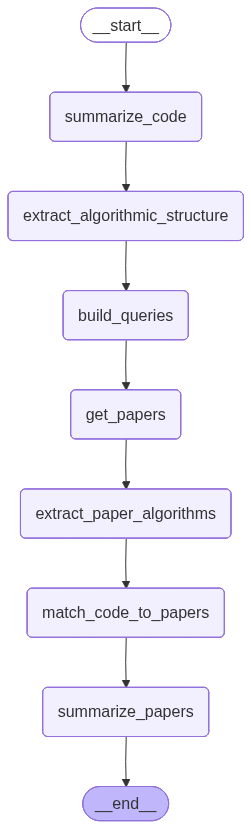

In [114]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("summarize_code", summarize_code)
graph_builder.add_node("extract_algorithmic_structure", extract_algorithmic_structure)
graph_builder.add_node("build_queries", build_queries)
graph_builder.add_node("get_papers", get_papers)
graph_builder.add_node("extract_paper_algorithms", extract_paper_algorithms)
graph_builder.add_node("match_code_to_papers", match_code_to_papers)
graph_builder.add_node("summarize_papers", summarize_papers)

graph_builder.add_edge(START, "summarize_code")
graph_builder.add_edge("summarize_code", "extract_algorithmic_structure")
graph_builder.add_edge("extract_algorithmic_structure", "build_queries")
graph_builder.add_edge("build_queries", "get_papers")
graph_builder.add_edge("get_papers", "extract_paper_algorithms")
graph_builder.add_edge("extract_paper_algorithms", "match_code_to_papers")
graph_builder.add_edge("match_code_to_papers", "summarize_papers")
graph_builder.add_edge("summarize_papers", END)

graph = graph_builder.compile()
graph

## Тесты агента

### Mock-примеры
Здесь приведены достаточно типичные куски кода, на которые модель должна однозначно сказать "исследовано здесь, новизны ноль"

In [115]:
example_code = """
import torch
import torch.nn.functional as F

model.eval()
layer = model.layer3[-1]
steps = 10
attack_steps = 20
eps = 16 / 255
alpha = 2 / 255
mu = 1.0

mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)


def forward_features(inp):
    feats = {}

    def hook(_, __, output):
        feats["value"] = output

    handle = layer.register_forward_hook(hook)
    logits = model((inp - mean) / std)
    handle.remove()
    return logits, feats["value"]


with torch.no_grad():
    clean_logits, clean_mid = forward_features(x)
    y = clean_logits.argmax(dim=1)

baseline = torch.zeros_like(x)
attr = torch.zeros_like(clean_mid)

for k in range(1, steps + 1):
    a = k / steps
    x_interp = baseline + a * (x - baseline)
    x_interp.requires_grad_(True)
    logits_interp, mid_interp = forward_features(x_interp)
    score = logits_interp.gather(1, y[:, None]).sum()
    grad_mid = torch.autograd.grad(score, mid_interp)[0]
    attr = attr + grad_mid * mid_interp / steps

weights = attr.mean(dim=(2, 3), keepdim=True)
weights = torch.relu(weights)
weights = weights / (weights.abs().mean(dim=(1, 2, 3), keepdim=True) + 1e-12)

delta = torch.zeros_like(x, requires_grad=True)
momentum = torch.zeros_like(x)

for _ in range(attack_steps):
    adv = (x + delta).clamp(0, 1)
    _, adv_mid = forward_features(adv)

    feature_loss = -(weights * adv_mid).sum(dim=(1, 2, 3)).mean()
    image_loss = 0.05 * (adv - x).pow(2).mean()
    loss = feature_loss + image_loss

    grad = torch.autograd.grad(loss, delta)[0]
    grad = grad / (grad.abs().mean(dim=(1, 2, 3), keepdim=True) + 1e-12)
    momentum = mu * momentum + grad

    delta.data = delta.data + alpha * momentum.sign()
    delta.data.clamp_(-eps, eps)
    delta.data = ((x + delta.data).clamp(0, 1) - x).detach()
    delta.grad = None

x_adv = (x + delta).clamp(0, 1)
"""

result = graph.invoke({"code": example_code})
print(result["final_summary"])

summarize_code raw result:
 {
  "task": "Feature Importance Guided Adversarial Attack",
  "method_kind": "Interpretability-based Adversarial Attack",
  "keywords": [
    "integrated gradients",
    "adversarial attack",
    "feature attribution",
    "intermediate layer",
    "momentum",
    "L_inf norm",
    "forward hook",
    "PyTorch"
  ],
  "concepts": [
    "explainable AI",
    "adversarial examples",
    "feature attribution",
    "gradient-based methods",
    "model robustness"
  ],
  "method_markers": [
    "интегрирование по пути от baseline к входу",
    "momentum update",
    "hook на промежуточный слой",
    "feature-level objective",
    "L_inf constraint",
    "важность через градиент выхода по промежуточному слою"
  ],
  "search_hints": [
    "adversarial attack with integrated gradients",
    "feature importance guided adversarial examples",
    "interpretability-based adversarial machine learning",
    "momentum iterative attack using feature attribution",
    "L_inf

/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_9210/1366186719.py:142: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().isoformat(timespec="seconds") + "Z"


Extracted source for 'Real-Time Adversarial Attacks'
Source type: tex_or_pdf_algorithm
Prompt source: \begin{algorithm}[!t]
\caption{Real-time Adversarial Attack}\label{alg:1}
\begin{algorithmic}[1]
\Require{
\quad \newline
Original dataset $\mathcal{X}=\{\boldsymbol{x}^i\}$ where each $\boldsymbol{x}^i=\{x^i_t\}$ \newline
\textbf{Non-real-time} adversarial example generator (expert) $g_e$}

\Algphase{Phase 1: Generate Expert Demonstrations}
\textbf{Input:}  Original sample set $\mathcal{X}$ \newline
\textbf{Output:}  Expert decision trajectory set $\mathcal{D}$
\State initialize $\mathcal{D}$ as an empty set
\For {each $\boldsymbol{x}^i \in \mathcal{X}$}
\State $\boldsymbol{r}^i= \{r^i_t\} = g_e(\boldsymbol{x}^i)$
\State initialize trajectory $\tau_i$ as an empty set
\For {each time point $t$ of $\boldsymbol{x}^i$} 
\State $o^i_t=\{x^i_1, x^i_2, ... x^i_t\}$
\State $a^i_t=r_{t+d+1}^i$
\State add $(o^i_t, a^i_t)$ to $\tau_i$
\EndFor
\State add $\tau_i$ to $\mathcal{D}$
\EndFor 
\State 

In [116]:
from IPython.display import display, Markdown

display(Markdown((result["final_summary"])))

**Главный вывод:** Алгоритм, описанный в коде, **не рассматривается в найденных литературных источниках почти один в один**. Он представляет собой **комбинацию нескольких специфических техник** (интегрированные градиенты для промежуточных слоёв, momentum-обновление, L_inf-проекция), которая не встречается в полном виде в проанализированных статьях. Наиболее близкая по общей идее статья (FIGA) использует принципиально иной метод (табличные данные, без градиентов и промежуточных слоёв). Таким образом, в коде присутствуют элементы, которые можно считать **научно новыми или, как минимум, неочевидно покрытыми существующей литературой**.

---

#### 1. Статьи, где это уже есть почти один в один
**Таких статей нет.**

*   **Почему:** Ни одна из статей не сочетает в себе все ключевые компоненты алгоритма из кода:
    *   **Атрибуция промежуточных признаков через integrated gradients** (путь от baseline, накопление `grad_mid * mid_interp`).
    *   **Использование хука (`register_forward_hook`)** для извлечения активаций конкретного промежуточного слоя (`layer3[-1]`).
    *   **Взвешенная потеря на признаках** (`feature_loss = -(weights * adv_mid).sum(...)`) с нормализацией и ReLU.
    *   **Итеративное momentum-обновление** (`momentum = mu * momentum + grad`) с последующей L_inf-проекцией (`delta.data.clamp_(-eps, eps)`).
    *   **Цель:** Манипуляция именно *промежуточными* признаками, важными для классификации, а не выходом модели напрямую.

#### 2. Частично релевантные статьи
**Только одна статья частично пересекается по общей идее, но не по методу.**

*   **"Feature Importance Guided Attack: A Model Agnostic Adversarial Attack" (FIGA, 2021)**
    *   **Степень совпадения:** **Частичное (идеологическое)**.
    *   **Что совпадает:** Общая парадигма **"атака, направленная важными признаками"**. Оба метода стремятся манипулировать входом в направлении, определяемом важностью признаков для модели.
    *   **Что не совпадает (критические отличия):**
        1.  **Метод определения важности:** FIGA использует **внешние модели/ранжирование признаков** (например, Random Forest), а код — **встроенную градиентную атрибуцию (Integrated Gradients) для промежуточного слоя** самой атакуемой модели.
        2.  **Область применения:** FIGA — для **табличных (гетерогенных) данных**. Код — для **изображений (CNN)** с работой над **тензорами промежуточных активаций**.
        3.  **Механика обновления:** FIGA — **одношаговая/поисковая** модификация важных признаков. Код — **многошаговая итеративная** атака с momentum и L_inf-ограничением.
        4.  **Технические детали:** В FIGA **нет** integrated gradients, хуков, работы с промежуточными слоями, momentum-обновления.
    *   **Вердикт:** Статья покрывает только самую абстрактную идею "атаки по важным признакам", но **не** алгоритмическую структуру, техническую реализацию или цели кода.

#### 3. Фоновые, но полезные статьи
Эти статьи не покрывают алгоритм кода, но представляют контекст смежных областей.

*   **"Attack-SAM: Towards Attacking Segment Anything Model..." (2023)**
    *   **Роль:** Контекст **специфической архитектуры (SAM)** и **cross-prompt transfer**. Показывает, что атаки на промежуточные представления актуальны для современных моделей, но метод (PGD для удаления масок) и цель (transferability) **существенно отличаются**.
*   **"Real-Time Adversarial Attacks" (2019)**
    *   **Роль:** Пример **атаки в потоковом режиме** на основе **имитационного обучения (RNN)**. Полностью другая парадигма (обучение на демонстрациях, RNN) vs. **градиентно-основанная атака на статичном изображении** в коде.
*   **"UniGuardian: A Unified Defense for Detecting..." (2025)**
    *   **Роль:** Пример **защиты (defense) для LLM** на основе неопределённости. **Не имеет отношения** к градиентно-основанным атакам на CNN для изображений.
*   **"Model-Agnostic Interpretability of Machine Learning" (LIME, 2016)**
    *   **Роль:** Классическая работа по **модельно-агностичной интерпретируемости**. Код использует **модельно-специфичный** метод (интегрированные градиенты внутри модели), что противоположно философии LIME.
*   **"Physics-Inspired Interpretability Of Machine Learning Models" (2023)**
    *   **Роль:** Альтернативный подход к интерпретируемости через **ландшафт потерь**. Подчёркивает, что **интегрированные градиенты** — лишь один из многих методов атрибуции, но не покрывает их использование для генерации атак.

#### 4. Что в коде выглядит потенциально новым или неочевидно покрытым
Следующие аспекты алгоритма **не находят прямого отражения** в проанализированных статьях и могут считаться его новизной или уникальной комбинацией:

1.  **Feature Attribution Guided Attack на уровне промежуточных слоёв CNN с использованием Integrated Gradients.** Статьи либо атакуют выход (PGD в Attack-SAM), либо используют feature importance для табличных данных (FIGA), либо не используют integrated gradients для атрибуции промежуточных активаций.
2.  **Конкретная формула потери:** `feature_loss = -(weights * adv_mid).sum(dim=(1, 2, 3)).mean()`. Это **взвешенное подавление** (с отрицательным знаком) **активаций промежуточного слоя**, где веса получены через integrated gradients. Такой точный механизм (интеграция градиентов *по промежуточному слою* -> веса каналов -> умножение на активации -> минимизация) не описан.
3.  **Комбинация Integrated Gradients для промежуточных признаков с Momentum-атакой и L_inf-проекцией.** В статьях эти компоненты либо разделены (PGD без feature attribution, FIGA без momentum/L_inf), либо используются в других контекстах (real-time RNN).
4.  **Использование `register_forward_hook` для "внедрения" в процесс атаки.** Это техническая деталь реализации, позволяющая получить доступ к активациям без модификации исходной модели, но она не упоминается в контексте подобных атак в статьях.
5.  **Цель "сравнения важных vs атакованных признаков"** (подразумевается в логике: атаковать те признаки, которые *важны* для правильного ответа). В Attack-SAM цель — удаление маски, в FIGA — сдвиг в сторону целевого класса, но не через целенаправленное подавление *конкретных промежуточных каналов*.

**Заключение:** Алгоритм кода — это **гибридный метод**, объединяющий идеи из **интерпретируемости (Integrated Gradients для промежуточных слоёв)** и **классических итеративных атак (Momentum, L_inf PGD)** с новой **целевой функцией**, направленной на подавление важных промежуточных признаков. Эта конкретная комбинация **не представлена** в найденных статьях, что указывает на потенциальную научную новизну или, как минимум, на неочевидность такого подхода в существующей литературе.

# Тестовые клетки
TODO: удалить

In [93]:
import requests
import tarfile
import io
import re
import os
import posixpath
import fitz  # PyMuPDF
from typing import List, Dict, Any, Optional, Tuple

ALGORITHM_ENV_PATTERNS = [
    r"\\begin\{algorithm\*?\}.*?\\end\{algorithm\*?\}",
    r"\\begin\{algorithmic\}.*?\\end\{algorithmic\}",
    r"\\begin\{algorithms\}.*?\\end\{algorithms\}",
    r"\\begin\{procedure\*?\}.*?\\end\{procedure\*?\}",
    r"\\begin\{lstlisting\}.*?\\end\{lstlisting\}",
]

STRONG_METHOD_SECTION_TITLE_PATTERNS = [
    r"^approach$",
    r"^approaches$",
    r"^method$",
    r"^methods$",
    r"^methodology$",
    r"^proposed method$",
    r"^proposed methods$",
    r"^proposed approach$",
    r"^proposed approaches$",
    r"^our method$",
    r"^our methods$",
    r"^our approach$",
    r"^our approaches$",
    r"^framework$",
    r"^proposed framework$",
    r"^our framework$",
    r"^algorithm$",
    r"^algorithms$",
    r"^attack$",
    r"^attack method$",
    r"^attack methods$",
    r"^attack formulation$",
    r"^threat model$",
    r"^problem formulation$",
    r"^formulation$",
    r"^model architecture$",
    r"^architecture$",
]

WEAK_METHOD_SENTENCE_PATTERNS = [
    r"we propose",
    r"our method",
    r"our approach",
    r"the proposed method",
    r"the proposed approach",
    r"algorithm",
    r"objective",
    r"optimization",
    r"training procedure",
    r"inference procedure",
    r"attack is formulated",
    r"we optimize",
]

NEGATIVE_SECTION_PATTERNS = [
    r"related work",
    r"background",
    r"experiments?",
    r"results?",
    r"discussion",
    r"conclusion",
    r"appendix",
    r"supplementary",
    r"references",
]

BAD_METHOD_SECTION_PATTERNS = [
    r"^other methods?\b",
    r"^other approaches?\b",
    r"^baseline methods?\b",
    r"^compared methods?\b",
    r"^comparison\b",
    r"^implementation details\b",
    r"^experimental setup\b",
    r"^experiment setup\b",
    r"^attack results\b",
    r"^ablation study\b",
    r"^limitations\b",
]

BAD_MAIN_TEX_PATTERNS = [
    r"author guidelines",
    r"latex author guidelines",
    r"camera ready",
    r"manuscript formatting",
    r"this style guide",
    r"blind review",
    r"dual submission",
]

MIN_METHOD_SECTION_SCORE_FOR_USE = 55.0


def download_arxiv_source(arxiv_id: str) -> bytes:
    url = f"https://arxiv.org/e-print/{arxiv_id}"
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    return response.content


def extract_tex_files_from_archive(source_bytes: bytes) -> List[Dict[str, str]]:
    archive = tarfile.open(fileobj=io.BytesIO(source_bytes))
    tex_files: List[Dict[str, str]] = []

    for member in archive.getmembers():
        if not member.isfile() or not member.name.endswith(".tex"):
            continue
        handle = archive.extractfile(member)
        if handle is None:
            continue
        tex_files.append(
            {
                "path": os.path.normpath(member.name),
                "content": handle.read().decode("utf-8", errors="ignore"),
            }
        )

    return tex_files


def extract_pdf_files_from_archive(source_bytes: bytes) -> List[str]:
    archive = tarfile.open(fileobj=io.BytesIO(source_bytes))
    pdf_files: List[str] = []

    for member in archive.getmembers():
        if not member.isfile():
            continue
        if member.name.lower().endswith(".pdf"):
            pdf_files.append(os.path.normpath(member.name))

    return pdf_files


def extract_file_bytes_from_archive(source_bytes: bytes, path: str) -> Optional[bytes]:
    archive = tarfile.open(fileobj=io.BytesIO(source_bytes))
    normalized_target = os.path.normpath(path)

    for member in archive.getmembers():
        if not member.isfile():
            continue
        if os.path.normpath(member.name) != normalized_target:
            continue
        handle = archive.extractfile(member)
        if handle is None:
            return None
        return handle.read()

    return None


def extract_text_from_pdf_bytes(pdf_bytes: bytes, max_chars: int = 40000) -> str:
    doc = fitz.open(stream=pdf_bytes, filetype="pdf")
    parts = []
    for page_idx in range(len(doc)):
        page = doc.load_page(page_idx)
        parts.append(page.get_text("text"))
    text = "\n".join(parts)
    text = text.replace("\r", "\n")
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text[:max_chars].strip()


def build_tex_file_map(tex_files: List[Dict[str, str]]) -> Dict[str, str]:
    return {tex_file["path"]: tex_file["content"] for tex_file in tex_files}


def preprocess_tex(tex: str) -> str:
    lines = []
    for line in tex.splitlines():
        line = re.sub(r"(?<!\\)%.*$", "", line)
        lines.append(line)
    tex = "\n".join(lines)
    tex = tex.replace("\r", "\n")
    tex = re.sub(r"\n{3,}", "\n\n", tex)
    return tex.strip()


def resolve_archive_relative_path(base_path: str, target: str) -> str:
    target = target.strip()
    if os.path.isabs(target):
        return target.lstrip("/")
    base_dir = os.path.dirname(base_path)
    return os.path.normpath(os.path.join(base_dir, target))


def normalize_include_target(base_path: str, target: str) -> str:
    target = target.strip()
    if not target.endswith(".tex"):
        target = target + ".tex"
    if os.path.isabs(target):
        return target.lstrip("/")
    base_dir = os.path.dirname(base_path)
    return os.path.normpath(os.path.join(base_dir, target))


def inline_tex_includes(path: str, file_map: Dict[str, str], visited: Optional[set] = None) -> str:
    if visited is None:
        visited = set()

    normalized_path = os.path.normpath(path)
    if normalized_path in visited:
        return ""
    visited.add(normalized_path)

    content = file_map.get(normalized_path, "")
    if not content:
        return ""

    include_pattern = re.compile(r"\\(?:input|include)\{([^}]+)\}")

    def replacer(match: re.Match) -> str:
        target = match.group(1)
        included_path = normalize_include_target(normalized_path, target)
        if included_path not in file_map:
            return match.group(0)
        included_text = inline_tex_includes(included_path, file_map, visited)
        return "\n\n" + included_text + "\n\n"

    return include_pattern.sub(replacer, content)


def extract_includepdf_targets(tex: str) -> List[str]:
    tex = preprocess_tex(tex)
    pattern = re.compile(r"\\includepdf(?:\[[^\]]*\])?\{([^}]+)\}")
    return [match.group(1).strip() for match in pattern.finditer(tex)]


def detect_embedded_pdf_main_document(main_tex: Dict[str, str], pdf_paths: List[str]) -> Optional[Dict[str, str]]:
    include_targets = extract_includepdf_targets(main_tex["content"])
    if not include_targets:
        return None

    pdf_path_set = set(pdf_paths)
    for target in include_targets:
        candidate = resolve_archive_relative_path(main_tex["path"], target)
        if candidate in pdf_path_set:
            return {"path": candidate}
        if not candidate.lower().endswith(".pdf"):
            candidate_pdf = candidate + ".pdf"
            if candidate_pdf in pdf_path_set:
                return {"path": candidate_pdf}

    first_target = include_targets[0]
    candidate = resolve_archive_relative_path(main_tex["path"], first_target)
    if not candidate.lower().endswith(".pdf"):
        candidate = candidate + ".pdf"
    return {"path": candidate}


def choose_main_tex_file(tex_files: List[Dict[str, str]]) -> Optional[Dict[str, str]]:
    if not tex_files:
        return None

    scored: List[Tuple[float, Dict[str, str]]] = []
    for tex_file in tex_files:
        content = tex_file["content"]
        lowered = content.lower()
        score = 0.0

        if "\\documentclass" in content:
            score += 8.0
        if "\\begin{document}" in content:
            score += 8.0
        if "\\title{" in content:
            score += 3.0
        if "\\author{" in content:
            score += 1.0
        if "\\begin{abstract}" in content:
            score += 3.0
        if "\\section{" in content:
            score += 2.0
        if "\\input{" in content or "\\include{" in content:
            score += 4.0
        if "\\includepdf" in content:
            score += 4.0

        score += min(len(content) / 10000.0, 5.0)

        if any(re.search(pattern, lowered) for pattern in BAD_MAIN_TEX_PATTERNS):
            score -= 25.0

        path_lower = tex_file["path"].lower()
        if path_lower.endswith("template.tex"):
            score -= 10.0
        if path_lower.endswith("supplementary.tex"):
            score -= 8.0

        scored.append((score, tex_file))

    scored.sort(key=lambda item: item[0], reverse=True)
    return scored[0][1]


def extract_algorithms_from_tex(tex: str) -> List[str]:
    tex = preprocess_tex(tex)
    matches: List[str] = []

    for pattern in ALGORITHM_ENV_PATTERNS:
        matches.extend(re.findall(pattern, tex, flags=re.DOTALL | re.IGNORECASE))

    deduped: List[str] = []
    seen = set()
    for match in matches:
        key = match.strip()
        if key and key not in seen:
            seen.add(key)
            deduped.append(key)

    return deduped


def split_tex_into_sections(tex: str) -> List[Dict[str, Any]]:
    tex = preprocess_tex(tex)
    section_pattern = re.compile(
        r"(?P<cmd>\\(?:sub)*section\*?)\{(?P<title>[^}]*)\}",
        flags=re.IGNORECASE,
    )

    matches = list(section_pattern.finditer(tex))
    if not matches:
        return []

    sections: List[Dict[str, Any]] = []
    for idx, match in enumerate(matches):
        start = match.start()
        cmd = match.group("cmd")
        title = match.group("title").strip()

        level = 1
        if "subsubsection" in cmd:
            level = 3
        elif "subsection" in cmd:
            level = 2

        end = len(tex)
        for next_match in matches[idx + 1:]:
            next_cmd = next_match.group("cmd")
            next_level = 1
            if "subsubsection" in next_cmd:
                next_level = 3
            elif "subsection" in next_cmd:
                next_level = 2
            if next_level <= level:
                end = next_match.start()
                break

        sections.append(
            {
                "index": idx,
                "command": cmd,
                "title": title,
                "level": level,
                "content": tex[start:end].strip(),
            }
        )

    return sections


def get_top_level_sections(tex: str) -> List[Dict[str, Any]]:
    return [section for section in split_tex_into_sections(tex) if section["level"] == 1]


def get_sections_before_experiments(sections: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    experiment_idx = None
    for idx, section in enumerate(sections):
        title = (section.get("title") or "").strip().lower()
        if re.search(r"^experiments?$|^experiment setup$|^experimental setup$|^evaluation$|^results?$", title):
            experiment_idx = idx
            break

    if experiment_idx is None:
        return sections

    return sections[:experiment_idx]


def title_matches_strong_method(title: str) -> bool:
    title = (title or "").strip().lower()
    if not title:
        return False
    if any(re.search(pattern, title) for pattern in NEGATIVE_SECTION_PATTERNS):
        return False
    if any(re.search(pattern, title) for pattern in BAD_METHOD_SECTION_PATTERNS):
        return False
    return any(re.search(pattern, title) for pattern in STRONG_METHOD_SECTION_TITLE_PATTERNS)


def score_method_section(section: Dict[str, Any], experiment_index: Optional[int] = None) -> float:
    title = section["title"].lower().strip()
    content = section["content"].lower()
    score = 0.0

    if title_matches_strong_method(title):
        score += 40.0

    if section["level"] == 1:
        score += 15.0
    elif section["level"] == 2:
        score += 6.0
    else:
        score -= 10.0

    if section["index"] in (1, 2, 3, 4, 5):
        score += 4.0

    if experiment_index is not None and section["index"] < experiment_index:
        distance = experiment_index - section["index"]
        if distance == 1:
            score += 18.0
        elif distance == 2:
            score += 10.0
        elif distance == 3:
            score += 5.0

    for pattern in WEAK_METHOD_SENTENCE_PATTERNS:
        if re.search(pattern, content):
            score += 1.0

    if "\\begin{algorithm" in content:
        score += 12.0

    if len(content) < 800:
        score -= 10.0
    elif len(content) < 1600:
        score -= 4.0

    return score


def select_best_method_section(tex_files: List[Dict[str, str]]) -> Optional[Dict[str, Any]]:
    main_tex = choose_main_tex_file(tex_files)
    if main_tex is None:
        return None

    file_map = build_tex_file_map(tex_files)
    expanded_main_tex = inline_tex_includes(main_tex["path"], file_map)
    if not expanded_main_tex:
        expanded_main_tex = main_tex["content"]

    all_sections = split_tex_into_sections(expanded_main_tex)
    preferred_sections = get_sections_before_experiments(all_sections)

    experiment_index = None
    for idx, section in enumerate(all_sections):
        title = (section.get("title") or "").strip().lower()
        if re.search(r"^experiments?$|^experiment setup$|^experimental setup$|^evaluation$|^results?$", title):
            experiment_index = idx
            break

    candidates: List[Dict[str, Any]] = []
    for section in preferred_sections:
        title = section["title"]
        if not title_matches_strong_method(title):
            continue

        candidate = {"path": main_tex["path"], **section}
        candidate["score"] = score_method_section(candidate, experiment_index=experiment_index) + 15.0
        candidates.append(candidate)

    if not candidates:
        for section in preferred_sections:
            title = section["title"]
            title_lower = (title or "").strip().lower()
            if any(re.search(pattern, title_lower) for pattern in NEGATIVE_SECTION_PATTERNS):
                continue
            if any(re.search(pattern, title_lower) for pattern in BAD_METHOD_SECTION_PATTERNS):
                continue
            if not (
                title_matches_strong_method(title)
                or re.search(r"\battack\b|\bfeature disruptive\b|\bfeature\b|\bpreliminaries\b|\bpreliminary\b", title_lower)
            ):
                continue

            candidate = {"path": main_tex["path"], **section}
            candidate["score"] = score_method_section(candidate, experiment_index=experiment_index)

            if re.search(r"\bfeature disruptive\b|\battack\b", title_lower):
                candidate["score"] += 12.0
            if re.search(r"\bpreliminaries\b|\bpreliminary\b", title_lower):
                candidate["score"] += 3.0
            if section["level"] == 2:
                candidate["score"] += 6.0

            candidates.append(candidate)

    if not candidates:
        return None

    candidates.sort(key=lambda item: item["score"], reverse=True)
    return candidates[0]


def build_whole_article_fallback(tex_files: List[Dict[str, str]], source_bytes: bytes, max_chars: int = 40000) -> Optional[Dict[str, Any]]:
    main_tex = choose_main_tex_file(tex_files)
    if main_tex is None:
        return None

    pdf_paths = extract_pdf_files_from_archive(source_bytes)
    embedded_pdf_doc = detect_embedded_pdf_main_document(main_tex, pdf_paths)
    if embedded_pdf_doc is not None:
        embedded_pdf_bytes = extract_file_bytes_from_archive(source_bytes, embedded_pdf_doc["path"])
        if embedded_pdf_bytes is not None:
            pdf_text = extract_text_from_pdf_bytes(embedded_pdf_bytes, max_chars=max_chars)
            return {
                "path": main_tex["path"],
                "text": pdf_text,
                "fallback_type": "embedded_pdf",
                "pdf_path": embedded_pdf_doc["path"],
            }
        return {
            "path": main_tex["path"],
            "text": "",
            "fallback_type": "embedded_pdf",
            "pdf_path": embedded_pdf_doc["path"],
        }

    file_map = build_tex_file_map(tex_files)
    expanded = inline_tex_includes(main_tex["path"], file_map)
    cleaned = preprocess_tex(expanded if expanded else main_tex["content"])
    cleaned = re.sub(r"\\bibliography\{[^}]*\}.*", "", cleaned, flags=re.DOTALL)
    cleaned = re.sub(r"\\begin\{thebibliography\}.*?\\end\{thebibliography\}", "", cleaned, flags=re.DOTALL)
    cleaned = re.sub(r"\\appendix.*", "", cleaned, flags=re.DOTALL | re.IGNORECASE)
    cleaned = re.sub(r"\\begin\{figure\*?\}.*?\\end\{figure\*?\}", "", cleaned, flags=re.DOTALL)
    cleaned = re.sub(r"\\begin\{table\*?\}.*?\\end\{table\*?\}", "", cleaned, flags=re.DOTALL)
    cleaned = cleaned[:max_chars].strip()

    return {
        "path": main_tex["path"],
        "text": cleaned,
        "fallback_type": "expanded_tex",
        "pdf_path": None,
    }


def extract_algorithm_material_from_tex_source(arxiv_id: str) -> Dict[str, Any]:
    source_bytes = download_arxiv_source(arxiv_id)
    tex_files = extract_tex_files_from_archive(source_bytes)

    algorithm_blocks: List[Dict[str, Any]] = []
    for tex_file in tex_files:
        for algo in extract_algorithms_from_tex(tex_file["content"]):
            algorithm_blocks.append({"path": tex_file["path"], "text": algo})

    best_method_section = select_best_method_section(tex_files)
    whole_article_fallback = build_whole_article_fallback(tex_files, source_bytes)

    use_method_section = (
        best_method_section is not None
        and best_method_section.get("score", 0.0) >= MIN_METHOD_SECTION_SCORE_FOR_USE
    )

    if algorithm_blocks:
        extraction_mode = "algorithm_block"
        primary_text = algorithm_blocks[0]["text"]
        decision_reason = "Found an explicit algorithm-like environment in TeX source."
    elif use_method_section:
        extraction_mode = "method_section"
        primary_text = best_method_section["content"]
        decision_reason = "Using a strong top-level method-like section from the expanded main TeX document."
    elif whole_article_fallback is not None:
        extraction_mode = "whole_article_fallback"
        primary_text = whole_article_fallback["text"]
        if whole_article_fallback.get("fallback_type") == "embedded_pdf":
            if best_method_section is None:
                decision_reason = "The main TeX file is a wrapper around an embedded PDF, so using full article text extracted from that PDF."
            else:
                decision_reason = "A candidate method section was found, but the main TeX file is a PDF wrapper, so using full article text extracted from the embedded PDF instead."
        else:
            if best_method_section is None:
                decision_reason = "No reliable method section was found, so using whole article fallback."
            else:
                decision_reason = "A candidate method section was found, but it was not strong enough, so using whole article fallback instead."
    else:
        extraction_mode = "not_found"
        primary_text = ""
        decision_reason = "No algorithm block, reliable method section, or usable fallback text was found."

    return {
        "arxiv_id": arxiv_id,
        "algorithm_blocks": algorithm_blocks,
        "best_method_section": best_method_section,
        "whole_article_fallback": whole_article_fallback,
        "fallback_pdf_path": None if whole_article_fallback is None else whole_article_fallback.get("pdf_path"),
        "extraction_mode": extraction_mode,
        "primary_text": primary_text,
        "decision_reason": decision_reason,
        "method_section_accepted": use_method_section,
    }


ID = "1412.6980"

main_tex_debug = choose_main_tex_file(extract_tex_files_from_archive(download_arxiv_source(ID)))
print("CHOSEN MAIN TEX:", None if main_tex_debug is None else main_tex_debug["path"])

tex_extraction_result = extract_algorithm_material_from_tex_source(ID)
print("EXTRACTION MODE:", tex_extraction_result["extraction_mode"])
print("DECISION REASON:", tex_extraction_result["decision_reason"])
print("METHOD SECTION ACCEPTED:", tex_extraction_result["method_section_accepted"])
print("FALLBACK PDF PATH:", tex_extraction_result["fallback_pdf_path"])

if tex_extraction_result["algorithm_blocks"]:
    print("\nFIRST ALGORITHM BLOCK:\n")
    print(tex_extraction_result["algorithm_blocks"][0]["text"][:5000])
elif tex_extraction_result["best_method_section"] is not None:
    print("\nBEST METHOD SECTION TITLE:", tex_extraction_result["best_method_section"]["title"])
    print("SCORE:", tex_extraction_result["best_method_section"]["score"])
    print("\nSECTION PREVIEW:\n")
    print(tex_extraction_result["best_method_section"]["content"][:5000])
elif tex_extraction_result["whole_article_fallback"] is not None:
    print("\nWHOLE ARTICLE FALLBACK TYPE:\n")
    print(tex_extraction_result["whole_article_fallback"].get("fallback_type"))
    print("\nWHOLE ARTICLE FALLBACK PREVIEW:\n")
    print(tex_extraction_result["whole_article_fallback"]["text"][:5000])
else:
    print("Nothing found.")

CHOSEN MAIN TEX: arxiv.tex
EXTRACTION MODE: whole_article_fallback
DECISION REASON: The main TeX file is a wrapper around an embedded PDF, so using full article text extracted from that PDF.
METHOD SECTION ACCEPTED: False
FALLBACK PDF PATH: 0_adam_main.pdf

WHOLE ARTICLE FALLBACK TYPE:

embedded_pdf

WHOLE ARTICLE FALLBACK PREVIEW:

Published as a conference paper at ICLR 2015
ADAM: A METHOD FOR STOCHASTIC OPTIMIZATION
Diederik P. Kingma*
University of Amsterdam, OpenAI
dpkingma@openai.com
Jimmy Lei Ba∗
University of Toronto
jimmy@psi.utoronto.ca
ABSTRACT
We introduce Adam, an algorithm for ﬁrst-order gradient-based optimization of
stochastic objective functions, based on adaptive estimates of lower-order mo-
ments. The method is straightforward to implement, is computationally efﬁcient,
has little memory requirements, is invariant to diagonal rescaling of the gradients,
and is well suited for problems that are large in terms of data and/or parameters.
The method is also appropriate fo

In [82]:
source_bytes = download_arxiv_source("1909.04385")
tex_files = extract_tex_files_from_archive(source_bytes)
file_map = build_tex_file_map(tex_files)
main_tex = choose_main_tex_file(tex_files)

print("MAIN TEX:", None if main_tex is None else main_tex["path"])

expanded_main = inline_tex_includes(main_tex["path"], file_map)
print("EXPANDED LENGTH:", len(expanded_main))

top_sections = get_top_level_sections(expanded_main)
print("\nTOP-LEVEL SECTIONS:\n")
for sec in top_sections:
    print(
        f"index={sec['index']}, "
        f"title={sec['title']!r}, "
        f"level={sec['level']}, "
        f"strong_match={title_matches_strong_method(sec['title'])}"
    )

MAIN TEX: main.tex
EXPANDED LENGTH: 78802

TOP-LEVEL SECTIONS:

index=0, title='Introduction', level=1, strong_match=False
index=1, title='Related Works', level=1, strong_match=False
index=2, title='Preliminaries', level=1, strong_match=False
index=3, title='Feature Disruptive Attack', level=1, strong_match=False
index=7, title='Experiments', level=1, strong_match=False
index=14, title='Conclusion', level=1, strong_match=False


# Примеры для проверки извлечения
https://arxiv.org/pdf/2204.00008 - `2204.00008` - есть блок с алгоритмом

https://arxiv.org/pdf/1805.12233 - `1805.12233` - нет блока с алгоритмом и важная глава огромная

https://arxiv.org/pdf/1909.04385 - `1909.04385` - нет блока с алгоритмом, есть четко выделенная глава